<a href="https://colab.research.google.com/github/mcarden4-netizen/Homework-Intro-to-ML/blob/Homework/Homework2part12%2C3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [252]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

filetest = '/content/drive/My Drive/Housing.csv'
data = pd.read_csv('/content/drive/My Drive/Housing.csv')
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [253]:
yesno = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

def binary_map(items):
  return items.map({'yes': 1, 'no': 0})

data[yesno] = data[yesno].apply(binary_map)
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [254]:
specs1 = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

X = data[specs1].values.astype(float)
Y = data['price'].values.astype(float)

X = np.hstack([np.ones((X.shape[0], 1)), X])

In [255]:
np.random.seed(50)

Ts = np.random.permutation(len(X))
split = int(0.8 * len(X))

traindata = Ts[:split]
valdata = Ts[split:]

Xtrain = X[traindata]
Xval = X[valdata]

Ytrain = Y[traindata]
Yval = Y[valdata]

In [256]:
def determine_data(input_data, output_data, theta):

  Predictions = input_data.dot(theta)
  errors = np.subtract(Predictions, output_data)
  C = 1/(2* len(output_data)) * np.sum(errors **2)

  return C

In [257]:
def r_squared(input_data, output_data, theta):

  predictions = input_data.dot(theta)
  ss_res = np.sum(np.square(output_data - predictions))
  ss_tot = np.sum(np.square(output_data - np.mean(output_data)))
  r2 = 1 - (ss_res/ss_tot)

  return r2

In [258]:
def standard(Trainingset, Validationset):

    mean = np.mean(Trainingset[:, 1:], axis=0)
    std = np.std(Trainingset[:, 1:], axis=0)

    Xcopy = Trainingset.copy()
    Ycopy = Validationset.copy()

    Xcopy[:, 1:] = (Xcopy[:, 1:] - mean) / std
    Ycopy[:, 1:] = (Ycopy[:, 1:] - mean) / std

    return Xcopy, Ycopy

In [259]:
def normalize(Trainingset, Validationset):

  low = np.min(Trainingset[:, 1:], axis = 0)
  high = np.max(Trainingset[:, 1:], axis = 0)

  Xcopy = Trainingset.copy()
  Ycopy = Validationset.copy()

  Xcopy[:, 1:] = (Xcopy[:, 1:] - low)/(high - low)
  Ycopy[:, 1:] = (Ycopy[:, 1:] - low)/(high - low)

  return Xcopy, Ycopy


/tmp/ipykernel_2096/583288166.py:5: RuntimeWarning: overflow encountered in square
  C = 1/(2* len(output_data)) * np.sum(errors **2)
/tmp/ipykernel_2096/2480476466.py:18: RuntimeWarning: invalid value encountered in subtract
  theta = theta - alpha * gradient


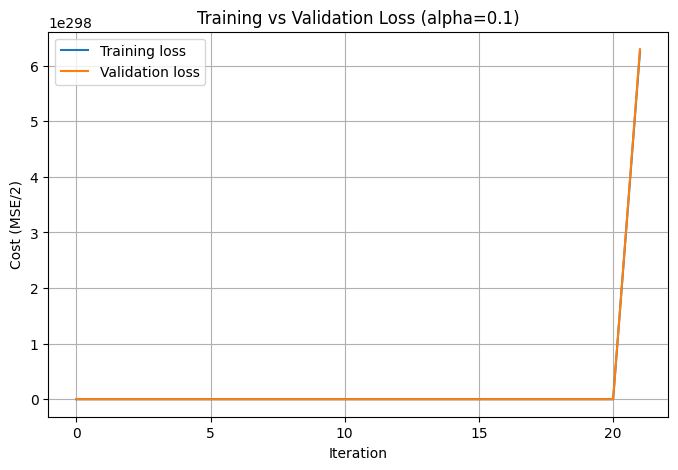

In [260]:
#1A

learning_rates = [0.1, .07, 0.05, .03, 0.01]
iterations = 1000

results = {}

for alpha in learning_rates:
    theta = np.zeros(Xtrain.shape[1])
    train_history = np.zeros(iterations)
    val_history = np.zeros(iterations)


    for i in range(iterations):
        predictions = Xtrain.dot(theta)
        errors = predictions - Ytrain
        gradient = (1 / len(Ytrain)) * (Xtrain.T.dot(errors))
        theta = theta - alpha * gradient

        train_history[i] = determine_data(Xtrain, Ytrain, theta)
        val_history[i] = determine_data(Xval, Yval, theta)

    results[alpha] = {'theta': theta, 'train_history': train_history,'val_history': val_history, 'r2_train': r_squared(Xtrain, Ytrain, theta), 'r2_val': r_squared(Xval, Yval, theta) }

best_alpha = min(results, key=lambda a: results[a]['val_history'][-1])
best = results[best_alpha]

plt.figure(figsize=(8, 5))
plt.plot(best['train_history'], label='Training loss')
plt.plot(best['val_history'], label='Validation loss')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE/2)')
plt.title(f'Training vs Validation Loss (alpha={best_alpha})')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_2096/583288166.py:5: RuntimeWarning: overflow encountered in square
  C = 1/(2* len(output_data)) * np.sum(errors **2)
/tmp/ipykernel_2096/2019028525.py:40: RuntimeWarning: invalid value encountered in subtract
  theta = theta - alpha * gradient


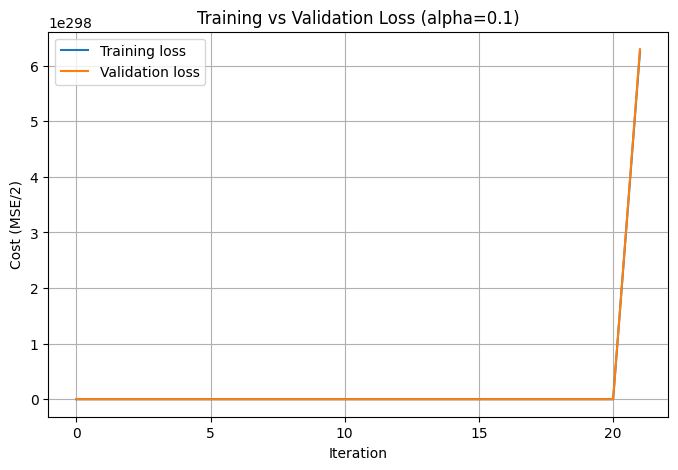

In [261]:
#1B

specs2 = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']

X2 = data[specs2].values.astype(float)
Y2 = data['price'].values.astype(float)

# add intercept (bias) column of ones at index 0
X2 = np.hstack([np.ones((X2.shape[0], 1)), X2])

np.random.seed(50)

Ts2 = np.random.permutation(len(X2))
split2 = int(0.8 * len(X2))

traindata2 = Ts2[:split2]
valdata2 = Ts2[split2:]

Xtrain2 = X2[traindata2]
Xval2 = X2[valdata2]

Ytrain2 = Y2[traindata2]
Yval2 = Y2[valdata2]

learning_rates = [0.1, .07, 0.05, .03, 0.01]
iterations = 1000

results = {}

for alpha in learning_rates:
    theta = np.zeros(Xtrain2.shape[1])
    train_history = np.zeros(iterations)
    val_history = np.zeros(iterations)


    for i in range(iterations):
        predictions = Xtrain2.dot(theta)
        errors = predictions - Ytrain2
        gradient = (1 / len(Ytrain2)) * (Xtrain2.T.dot(errors))
        theta = theta - alpha * gradient

        train_history[i] = determine_data(Xtrain2, Ytrain2, theta)
        val_history[i] = determine_data(Xval2, Yval2 ,theta)

    results[alpha] = {'theta': theta, 'train_history': train_history,'val_history': val_history, 'r2_train': r_squared(Xtrain2, Ytrain2, theta), 'r2_val': r_squared(Xval2, Yval2, theta) }

best_alpha = min(results, key=lambda a: results[a]['val_history'][-1])
best = results[best_alpha]

plt.figure(figsize=(8, 5))
plt.plot(best['train_history'], label='Training loss')
plt.plot(best['val_history'], label='Validation loss')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE/2)')
plt.title(f'Training vs Validation Loss (alpha={best_alpha})')
plt.legend()
plt.grid(True)
plt.show()

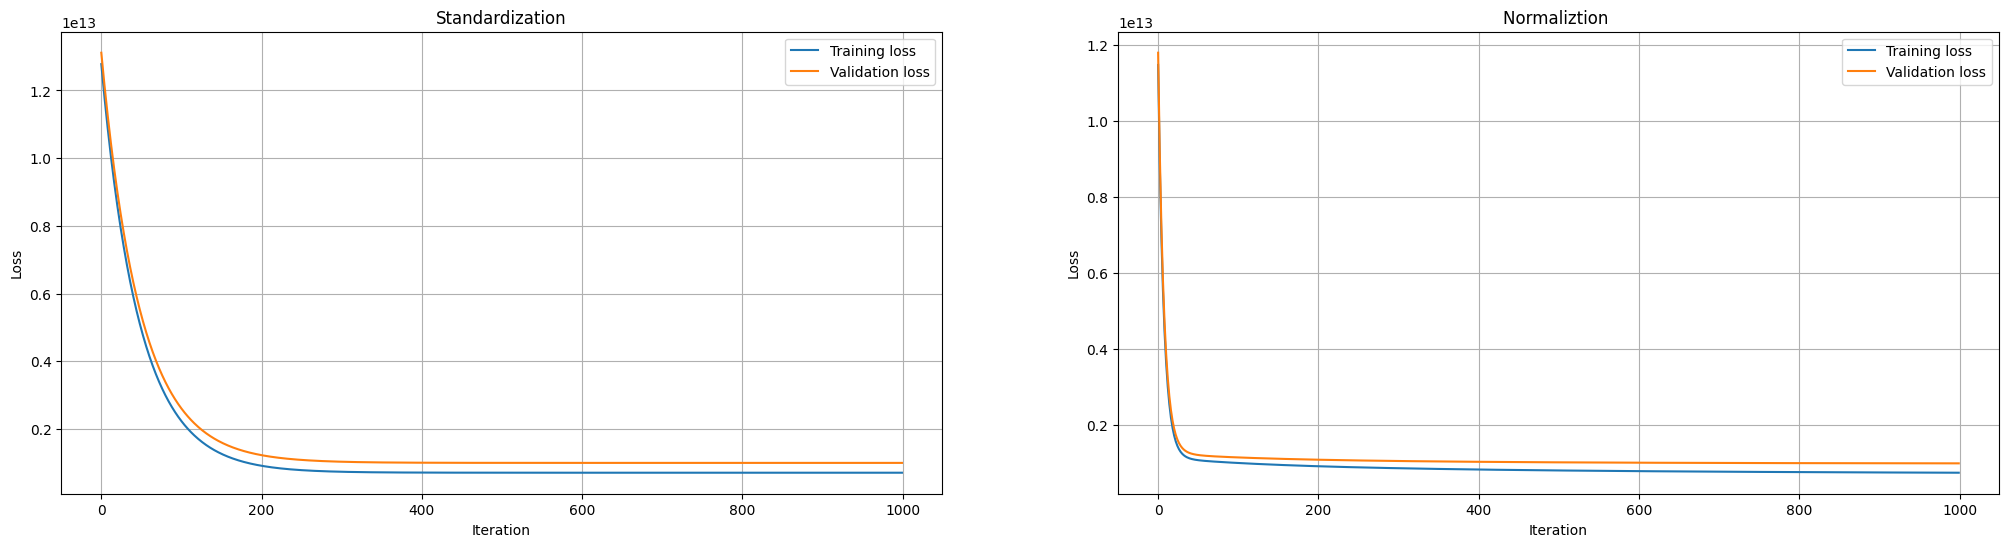

In [262]:
#2a

learning_rates = [0.1, 0.05, 0.01]
iterations = 1000

Xtrainstd, Xvalstd = standard(Xtrain, Xval)

results_std = {}

for alpha in learning_rates:
    theta = np.zeros(Xtrainstd.shape[1])
    train_history = np.zeros(iterations)
    val_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = Xtrainstd.dot(theta)
        errors = predictions - Ytrain
        gradient = (1 / len(Ytrain)) * (Xtrainstd.T.dot(errors))
        theta = theta - alpha * gradient

        train_history[i] = determine_data(Xtrainstd, Ytrain, theta)
        val_history[i] = determine_data(Xvalstd, Yval, theta)

    results_std[alpha] = {
        'theta': theta,
        'train_history': train_history,
        'val_history': val_history,
        'r2_train': r_squared(Xtrainstd, Ytrain, theta),
        'r2_val': r_squared(Xvalstd, Yval, theta)
    }

best_alpha_std = None
best_val_loss_std = float('inf')

for alpha, res in results_std.items():
    final_val_loss = res['val_history'][-1]
    if final_val_loss < best_val_loss_std:
        best_val_loss_std = final_val_loss
        best_alpha_std = alpha

best_std = results_std[best_alpha_std]

Xtrainnorm, Xvalnorm = normalize(Xtrain, Xval)

results_norm = {}

for alpha in learning_rates:
    theta = np.zeros(Xtrainnorm.shape[1])
    train_history = np.zeros(iterations)
    val_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = Xtrainnorm.dot(theta)
        errors = predictions - Ytrain
        gradient = (1 / len(Ytrain)) * (Xtrainnorm.T.dot(errors))
        theta = theta - alpha * gradient

        train_history[i] = determine_data(Xtrainnorm, Ytrain, theta)
        val_history[i] = determine_data(Xvalnorm, Yval, theta)

    results_norm[alpha] = {
        'theta': theta,
        'train_history': train_history,
        'val_history': val_history,
        'r2_train': r_squared(Xtrainnorm, Ytrain, theta),
        'r2_val': r_squared(Xvalnorm, Yval, theta)
    }

best_alpha_norm = None
best_val_loss_norm = float('inf')

for alpha, res in results_norm.items():
    final_val_loss = res['val_history'][-1]
    if final_val_loss < best_val_loss_norm:
        best_val_loss_norm = final_val_loss
        best_alpha_norm = alpha

best_norm = results_norm[best_alpha_norm]

plt.figure(figsize=(25,6))

plt.subplot(1,2,1)
plt.plot(best_std['train_history'], label='Training loss')
plt.plot(best_std['val_history'], label='Validation loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Standardization')
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(best_norm['train_history'], label='Training loss')
plt.plot(best_norm['val_history'], label='Validation loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Normaliztion ')
plt.grid(True)
plt.legend()

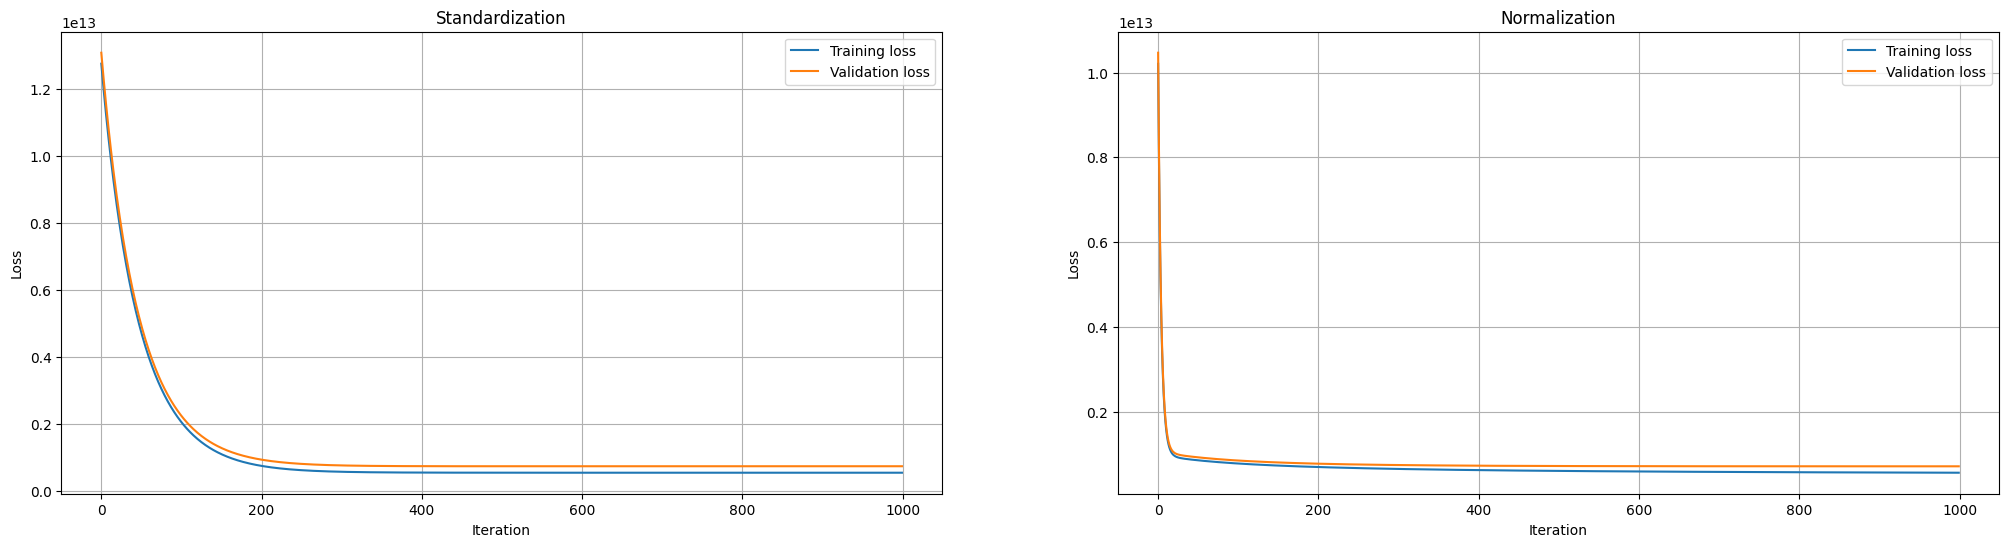

In [263]:
#2b

Xtrainstd2, Xvalstd2 = standard(Xtrain2, Xval2)

results_std2 = {}

for alpha in learning_rates:
    theta = np.zeros(Xtrainstd2.shape[1])
    train_history = np.zeros(iterations)
    val_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = Xtrainstd2.dot(theta)
        errors = predictions - Ytrain2
        gradient = (1 / len(Ytrain2)) * (Xtrainstd2.T.dot(errors))
        theta = theta - alpha * gradient

        train_history[i] = determine_data(Xtrainstd2, Ytrain2, theta)
        val_history[i] = determine_data(Xvalstd2, Yval2, theta)

    results_std2[alpha] = {
        'theta': theta,
        'train_history': train_history,
        'val_history': val_history,
        'r2_train': r_squared(Xtrainstd2, Ytrain2, theta),
        'r2_val': r_squared(Xvalstd2, Yval2, theta)
    }

best_alpha_std2 = None
best_val_loss_std2 = float('inf')

for alpha, res in results_std2.items():
    final_val_loss = res['val_history'][-1]
    if final_val_loss < best_val_loss_std2:
        best_val_loss_std2 = final_val_loss
        best_alpha_std2 = alpha

best_std2 = results_std2[best_alpha_std2]

Xtrainnorm2, Xvalnorm2 = normalize(Xtrain2, Xval2)

results_norm2 = {}

for alpha in learning_rates:
    theta = np.zeros(Xtrainnorm2.shape[1])
    train_history = np.zeros(iterations)
    val_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = Xtrainnorm2.dot(theta)
        errors = predictions - Ytrain2
        gradient = (1 / len(Ytrain2)) * (Xtrainnorm2.T.dot(errors))
        theta = theta - alpha * gradient

        train_history[i] = determine_data(Xtrainnorm2, Ytrain2, theta)
        val_history[i] = determine_data(Xvalnorm2, Yval2, theta)

    results_norm2[alpha] = {
        'theta': theta,
        'train_history': train_history,
        'val_history': val_history,
        'r2_train': r_squared(Xtrainnorm2, Ytrain2, theta),
        'r2_val': r_squared(Xvalnorm2, Yval2, theta)
    }

best_alpha_norm2 = None
best_val_loss_norm2 = float('inf')

for alpha, res in results_norm2.items():
    final_val_loss = res['val_history'][-1]
    if final_val_loss < best_val_loss_norm2:
        best_val_loss_norm2 = final_val_loss
        best_alpha_norm2 = alpha

best_norm2 = results_norm2[best_alpha_norm2]

plt.figure(figsize=(25,6))

plt.subplot(1,2,1)
plt.plot(best_std2['train_history'], label='Training loss')
plt.plot(best_std2['val_history'], label='Validation loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Standardization')
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(best_norm2['train_history'], label='Training loss')
plt.plot(best_norm2['val_history'], label='Validation loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Normalization')
plt.grid(True)
plt.legend()

Using Normalization


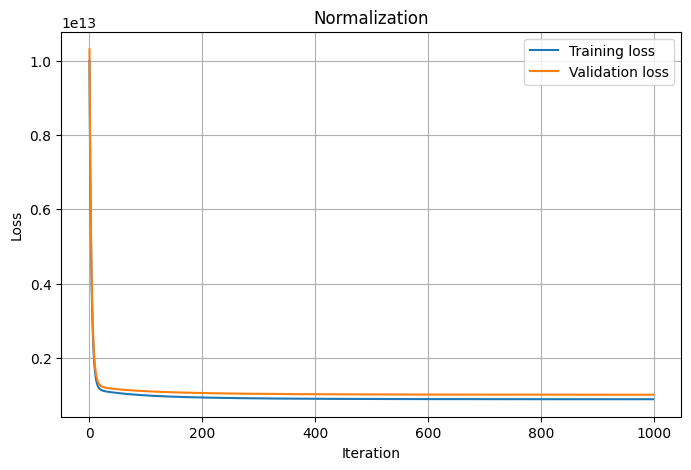

In [275]:
if best_val_loss_std < best_val_loss_norm:
    scaling = 'Standardization'
    Xtrainbest, Xvalbest = Xtrainstd, Xvalstd
else:
    scaling = 'Normalization'
    Xtrainbest, Xvalbest = Xtrainnorm, Xvalnorm

print('Using', scaling)


def determine_cost_reg(input_data, output_data, theta, lam):
    predictions = input_data.dot(theta)
    errors = predictions - output_data
    b = len(output_data)
    base = 1 / (2 * b) * np.sum(errors ** 2)
    penalty = (lam / (2 * b)) * np.sum(theta[1:] ** 2)
    return base + penalty


learning_rates = [0.1, .07, 0.05, .03, 0.01]
iterations = 1000
lam = 5

results_reg = {}

for alpha in learning_rates:
    theta = np.zeros(Xtrainbest.shape[1])
    train_history = np.zeros(iterations)
    val_history = np.zeros(iterations)
    b = len(Ytrain)

    for i in range(iterations):
        predictions = Xtrainbest.dot(theta)
        errors = predictions - Ytrain

        gradient = (1 / b) * (Xtrainbest.T.dot(errors))
        reg_term = (lam / b) * theta
        reg_term[0] = 0
        gradient = gradient + reg_term

        theta = theta - alpha * gradient

        train_history[i] = determine_cost_reg(Xtrainbest, Ytrain, theta, lam)
        val_history[i] = determine_data(Xvalbest, Yval, theta)

    results_reg[alpha] = {'theta': theta, 'train_history': train_history, 'val_history': val_history, 'r2_train': r_squared(Xtrainbest, Ytrain, theta), 'r2_val': r_squared(Xvalbest, Yval, theta)}

best_alpha_reg = None
best_val_loss_reg = float('inf')

for alpha, res in results_reg.items():
    final_val_loss = res['val_history'][-1]
    if final_val_loss < best_val_loss_reg:
        best_val_loss_reg = final_val_loss
        best_alpha_reg = alpha

best_reg = results_reg[best_alpha_reg]

plt.figure(figsize=(8, 5))
plt.plot(best_reg['train_history'], label='Training loss')
plt.plot(best_reg['val_history'], label='Validation loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title(scaling)
plt.grid(True)
plt.legend()
plt.show()

Using Normalization


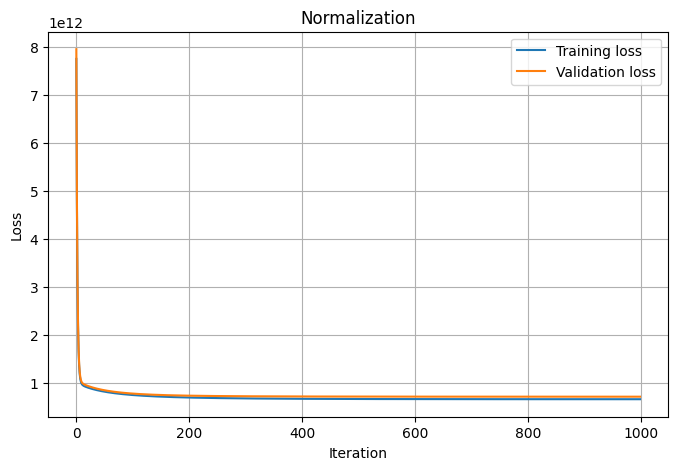

In [281]:
if best_val_loss_std2 < best_val_loss_norm2:
    scaling2 = 'Standardization'
    Xtrainbest2, Xvalbest2 = Xtrainstd2, Xvalstd2
else:
    scaling2 = 'Normalization'
    Xtrainbest2, Xvalbest2 = Xtrainnorm2, Xvalnorm2

print('Using', scaling2)

learning_rates = [0.1, .07, 0.05, .03, 0.01]
iterations = 1000
lam = 5

results_reg = {}

for alpha in learning_rates:
    theta = np.zeros(Xtrainbest2.shape[1])
    train_history = np.zeros(iterations)
    val_history = np.zeros(iterations)
    b = len(Ytrain2)

    for i in range(iterations):
        predictions = Xtrainbest2.dot(theta)
        errors = predictions - Ytrain2

        gradient = (1 / b) * (Xtrainbest2.T.dot(errors))
        reg_term = (lam / b) * theta
        reg_term[0] = 0
        gradient = gradient + reg_term

        theta = theta - alpha * gradient

        train_history[i] = determine_cost_reg(Xtrainbest2, Ytrain2, theta, lam)
        val_history[i] = determine_data(Xvalbest2, Yval2, theta)

    results_reg[alpha] = {'theta': theta, 'train_history': train_history, 'val_history': val_history, 'r2_train': r_squared(Xtrainbest2, Ytrain2, theta), 'r2_val': r_squared(Xvalbest2, Yval2, theta)}

best_alpha_reg2 = None
best_val_loss_reg2 = float('inf')

for alpha, res in results_reg.items():
    final_val_loss = res['val_history'][-1]
    if final_val_loss < best_val_loss_reg2:
        best_val_loss_reg2 = final_val_loss
        best_alpha_reg2 = alpha

best_reg2 = results_reg[best_alpha_reg2]

plt.figure(figsize=(8, 5))
plt.plot(best_reg2['train_history'], label='Training loss')
plt.plot(best_reg2['val_history'], label='Validation loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title(scaling)
plt.grid(True)
plt.legend()
plt.show()